1. Provide a watermark (top-secret.png) on the receipt image contained in this attachment (ReceiptSwiss.jpg)

2. Modify the code in the notebook below so that when you click for the first time it will display a point on the video, and when you click for the second time it will display a circle with a radius that is the distance from the first click point to the distance from the second click point.

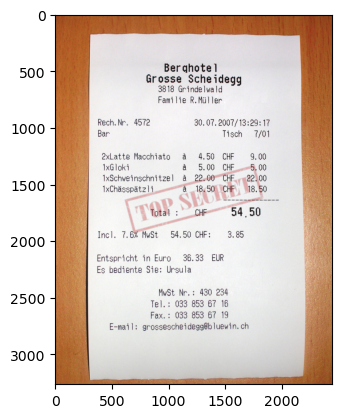

In [ ]:
# Nomor 1
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the receipt and watermark images
receipt_path = "ReceiptSwiss.jpg"  # Replace with your receipt image path
watermark_path = "top-secret.png"  # Replace with your watermark image path

receipt_cv = cv2.imread(receipt_path)
watermark_cv = cv2.imread(watermark_path, cv2.IMREAD_UNCHANGED)  # Load with alpha channel

# Resize the watermark to fit a portion of the receipt
receipt_height, receipt_width = receipt_cv.shape[:2]
watermark_width = receipt_width // 2
watermark_ratio = watermark_cv.shape[1] / watermark_cv.shape[0]
watermark_size = (watermark_width, int(watermark_width / watermark_ratio))
watermark_cv_resized = cv2.resize(watermark_cv, watermark_size, interpolation=cv2.INTER_AREA)


# Blur the watermark
blurred_watermark = cv2.GaussianBlur(watermark_cv_resized, (15, 15), 0)

# Split the blurred watermark into its color and alpha channels
if blurred_watermark.shape[2] == 4:  # Ensure it has an alpha channel
    watermark_color = blurred_watermark[:, :, :3]
    watermark_alpha = blurred_watermark[:, :, 3] / 255.0  # Normalize alpha to 0-1 range
else:
    watermark_color = blurred_watermark
    watermark_alpha = np.ones(watermark_color.shape[:2], dtype=float)  # Full opacity if no alpha
    
reduced_opacity = 0.3  # Adjust the opacity (0.0 to 1.0, where 1.0 is fully visible)
watermark_alpha *= reduced_opacity

# Create an overlay image with the watermark positioned at the center of the receipt
overlay = np.zeros_like(receipt_cv, dtype=np.uint8)
y_offset = (receipt_height - watermark_cv_resized.shape[0]) // 2
x_offset = (receipt_width - watermark_cv_resized.shape[1]) // 2
overlay[y_offset:y_offset + watermark_cv_resized.shape[0], x_offset:x_offset + watermark_cv_resized.shape[1]] = watermark_color

# Blend the overlay with the original image using the alpha mask
for c in range(3):  # Loop through color channels (B, G, R)
    receipt_cv[y_offset:y_offset + watermark_cv_resized.shape[0],
               x_offset:x_offset + watermark_cv_resized.shape[1], c] = \
        (1 - watermark_alpha) * receipt_cv[y_offset:y_offset + watermark_cv_resized.shape[0],
                                           x_offset:x_offset + watermark_cv_resized.shape[1], c] + \
        watermark_alpha * overlay[y_offset:y_offset + watermark_cv_resized.shape[0],
                                   x_offset:x_offset + watermark_cv_resized.shape[1], c]

# Save the result
output_cv_path = "Watermarked_ReceiptSwiss_CV.png"  # Output file path
cv2.imwrite(output_cv_path, receipt_cv)

print(f"Watermarked image saved at {output_cv_path}")

# show image
change = cv2.cvtColor(receipt_cv, cv2.COLOR_BGR2RGB)
plt.imshow(change)


In [ ]:
import cv2
# Create a function based on a CV2 Event (Left button click)

# mouse callback function
def draw_rectangle(event,x,y,flags,param):

    global pt1,pt2,topLeft_clicked,botRight_clicked

    # get mouse click
    if event == cv2.EVENT_LBUTTONDOWN:

        if topLeft_clicked == True and botRight_clicked == True:
            topLeft_clicked = False
            botRight_clicked = False
            pt1 = (0,0)
            pt2 = (0,0)

        if topLeft_clicked == False:
            pt1 = (x,y)
            topLeft_clicked = True
            
        elif botRight_clicked == False:
            pt2 = (x,y)
            botRight_clicked = True

        
# Haven't drawn anything yet!

pt1 = (0,0)
pt2 = (0,0)
topLeft_clicked = False
botRight_clicked = False

cap = cv2.VideoCapture(0) 

# Create a named window for connections
cv2.namedWindow('Test')

# Bind draw_rectangle function to mouse cliks
cv2.setMouseCallback('Test', draw_rectangle) 


while True:
    # Capture frame-by-frame
    ret, frame = cap.read()

    if topLeft_clicked:
        cv2.circle(frame, center=pt1, radius=5, color=(0,0,255), thickness=-1)
        
    #drawing rectangle
    if topLeft_clicked and botRight_clicked:
        cv2.rectangle(frame, pt1, pt2, (0, 0, 255), 2)
        
        
    # Display the resulting frame
    cv2.imshow('Test', frame)

    # This command let's us quit with the "q" button on a keyboard.
    # Simply pressing X on the window won't work!
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# When everything is done, release the capture
cap.release()
cv2.destroyAllWindows()

In [ ]:
# Jawaban Nomor 2

import cv2
import math

# mouse callback function
def draw_circle(event, x, y, flags, param):
    global pt1, pt2, first_click, second_click

    # Handle mouse click events
    if event == cv2.EVENT_LBUTTONDOWN:
        if first_click and second_click:  # Reset clicks if two points are already selected
            first_click = False
            second_click = False
            pt1 = (0, 0)
            pt2 = (0, 0)

        if not first_click:
            pt1 = (x, y)  # Save the first point
            first_click = True
        elif not second_click:
            pt2 = (x, y)  # Save the second point
            second_click = True

# Initialize variables
pt1 = (0, 0)
pt2 = (0, 0)
first_click = False
second_click = False

# Set up video capture
cap = cv2.VideoCapture(0)

# Create a named window for connections
cv2.namedWindow('Test')

# Bind the draw_circle function to mouse clicks
cv2.setMouseCallback('Test', draw_circle)

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    if not ret:
        print("Failed to capture frame. Exiting...")
        break

    # Draw the first click point
    if first_click:
        cv2.circle(frame, center=pt1, radius=5, color=(0, 0, 255), thickness=-1)

    # Draw the circle based on the second click
    if first_click and second_click:
        # Calculate the radius as the distance between the two points
        radius = int(math.sqrt((pt2[0] - pt1[0])**2 + (pt2[1] - pt1[1])**2))
        # Draw the circle
        cv2.circle(frame, center=pt1, radius=radius, color=(0, 255, 0), thickness=2)

    # Display the resulting frame
    cv2.imshow('Test', frame)

    # Quit with the "q" key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()
